## Preparation

### Requirements

In [33]:
%pip install torchinfo torchvision opencv-python matplotlib kagglehub seaborn scikit-learn optuna


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [34]:
import torch
import utils
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from plot_utils import plot_confmat, plot_gradcam
from grad_cam import GradCAM
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
# %matplotlib inline
from torchinfo import summary
import kagglehub
import os
import shutil
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from pathlib import Path
import imbalance_utils
import torch.nn as nn
import torch.optim as optim
import optuna
from torch.utils.data import DataLoader, WeightedRandomSampler
import torch
import numpy as np
from collections import Counter

from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)
import torch
import numpy as np
import pandas as pd

In [35]:
TRAIN_SPLIT = 0.7
VAL_SPLIT = 0.15
TEST_SPLIT = 0.15


BATCH_SIZE = 16

# we'll set up device used for training
#device = utils.device
device = "cpu"
print(f"Using device: {device}")

Using device: cpu


### Dataset preparation

This step downloads the dataset from Kaggle, and prepares it to be used. It splits the dataset into training, validation, and test sets, and prepares the directory structure for the dataloaders:
 * `data/train/[class]`
 * `data/test/[class]`
 * `data/val/[class]`

#### Downloading

In [36]:
# https://www.kaggle.com/datasets/tawsifurrahman/tuberculosis-tb-chest-xray-dataset
path = kagglehub.dataset_download("tawsifurrahman/tuberculosis-tb-chest-xray-dataset", output_dir="./data")

#### Splitting

In [37]:
def split_dataset(source_dir, output_dir, classes=("Normal", "Tuberculosis"),
                  train_size=0.7, val_size=0.15, test_size=0.15, random_state=42):

    for split in ["train", "val", "test"]:
        for cls in classes:
            os.makedirs(os.path.join(output_dir, split, cls), exist_ok=True)

    for cls in classes:
        class_dir = os.path.join(source_dir, cls)

        image_files = [f for f in os.listdir(class_dir) if f.lower().endswith((".png"))]

        train_files, temp_files = train_test_split(image_files, train_size=train_size, random_state=random_state,shuffle=True)
        val_relative_size = val_size / (val_size + test_size) # de les que queden, dividim segons split
        val_files, test_files = train_test_split(temp_files, train_size=val_relative_size, random_state=random_state, shuffle=True)

        # mètode per copiar d'un dir a un altre
        def copy_files(files, split):
            target_dir = os.path.join(output_dir, split, cls)
            for file in files:
                shutil.copy2(os.path.join(class_dir, file), os.path.join(target_dir, file))

        copy_files(train_files, "train")
        copy_files(val_files, "val")
        copy_files(test_files, "test")

source_dir = "./data/TB_Chest_Radiography_Database"

try:
    split_dataset(
        source_dir=source_dir,
        output_dir="./data",
        train_size=TRAIN_SPLIT,
        val_size=VAL_SPLIT,
        test_size=TEST_SPLIT,
    )

    # eliminem per espai
    shutil.rmtree(source_dir)
except Exception as e:
    print(f"Error occurred. Maybe the source directory does not exist, as data was already split into train/test/val splits: \n\t{e} ")

Error occurred. Maybe the source directory does not exist, as data was already split into train/test/val splits: 
	[Errno 2] No such file or directory: './data/TB_Chest_Radiography_Database/Normal' 


## Dataset analysis

The idea of this step is to load the dataset and analyze it. We will look at the class distribution, and some sample images for each class.

### Sample image ploting

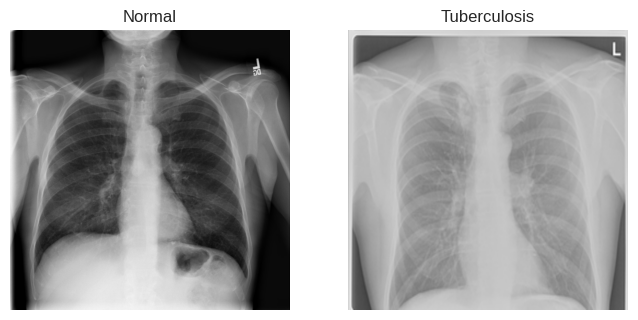

In [38]:
# Loading the data for visualization
test_set = datasets.ImageFolder(root=utils.dirs['test'], transform=transforms.ToTensor())
test_dl = torch.utils.data.DataLoader(test_set, batch_size=16, shuffle=True, num_workers=2)
images, labels = next(iter(test_dl)) # Load the first batch from the dataloader (size 16)

class_names = ['Normal', 'Tuberculosis']
class_samples = {class_name: None for class_name in class_names}

# Get a sample image for each one of the classes
for c in class_samples:
    idx_class = test_set.class_to_idx[c]
    idx_img = torch.where(labels == idx_class)[0][0].item()
    class_samples[c] = images[idx_img]
    
# Plot the samples
fig = plt.figure(figsize=(8, 8))
for i in np.arange(2):
    label = class_names[i]
    img = class_samples[label]
    ax = fig.add_subplot(2, 2, i+1)
    ax.axis('off')
    ax.imshow(img.permute(1, 2, 0))
    ax.set_title(label)
# fig.savefig('outputs/samples.png')

### Class distribution

Count for each class in the training set: {'Normal': 2450, 'Tuberculosis': 489}
Percentage for each class in the training set: {'Normal': 83.36, 'Tuberculosis': 16.64}%


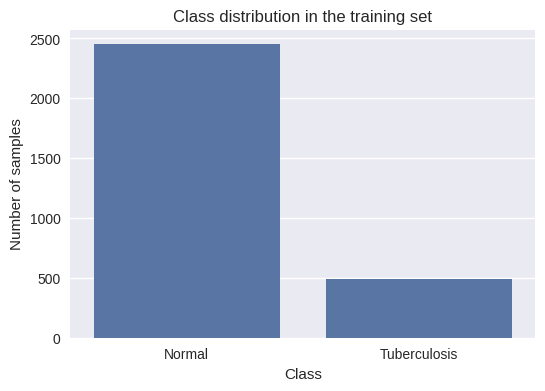

In [39]:
# plot class distribution in the training set
train_set = datasets.ImageFolder(root=utils.dirs['train'], transform=transforms.ToTensor())
train_dl = torch.utils.data.DataLoader(train_set, batch_size=16, shuffle=True, num_workers=2)
train_images, train_labels = next(iter(train_dl))
targets = train_set.targets
class_counts = [targets.count(i) for i in range(len(class_names))]
plt.figure(figsize=(6, 4))
sns.barplot(x=class_names, y=class_counts)
plt.title("Class distribution in the training set")
plt.ylabel("Number of samples")
plt.xlabel("Class")

print(f"Count for each class in the training set: {dict(zip(class_names, class_counts))}")
print(f"Percentage for each class in the training set: {dict(zip(class_names, [round(count / len(train_set) * 100, 2) for count in class_counts]))}%")

## Transfer learning

The idea of this step is to use two pretrained models (ResNet50 and EfficientNetB0) and fine-tune them on our dataset. We will then compare the results of the two models and choose the best one for the following steps.

### Helper methods

These methods are used to train and evaluate the models.

In [40]:
# prepare the train loader
train_set = datasets.ImageFolder(root=utils.dirs['train'], transform=utils.transform['train'])
train_loader = torch.utils.data.DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
train_images, train_labels = next(iter(train_loader))

# and the validation loader
val_set = datasets.ImageFolder(root=utils.dirs['val'], transform=utils.transform['test'])
val_loader = torch.utils.data.DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
val_images, val_labels = next(iter(val_loader))

# and the test loader
test_set = datasets.ImageFolder(root=utils.dirs['test'], transform=utils.transform['test'])
test_loader = torch.utils.data.DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_images, test_labels = next(iter(test_loader))

Note that we are providing a transformation when loading the dataset. This allows us to resize the images to the size expected by the models (224x224), and to normalize the images using the mean and standard deviation of the ImageNet dataset, which is the dataset on which the models were pretrained.

Below is the transformation applied to both the training and validation/test sets. The two are differentiated for consistency, though they are the same in this case, as we are not applying any data augmentation techniques (yet).

```python
transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])
```

Below is an image of each class after applying the transformation, which shows that the images are indeed resized and normalized.

Source for standardization: https://discuss.pytorch.org/t/discussion-why-normalise-according-to-imagenet-mean-and-std-dev-for-transfer-learning/115670

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0322802..2.5528543].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9295317..2.4482791].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0665298..2.6051416].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.535425].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7582842..2.64].


Class 'Normal' has 2450 samples.
Class 'Tuberculosis' has 489 samples.


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8096584..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0494049..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.2630938].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.2108063].


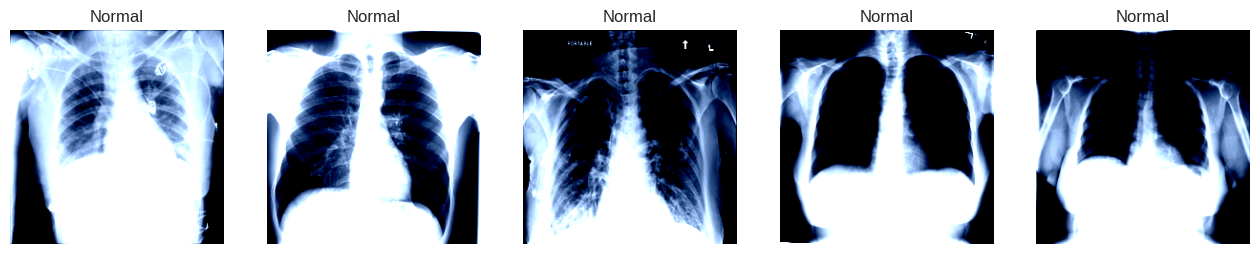

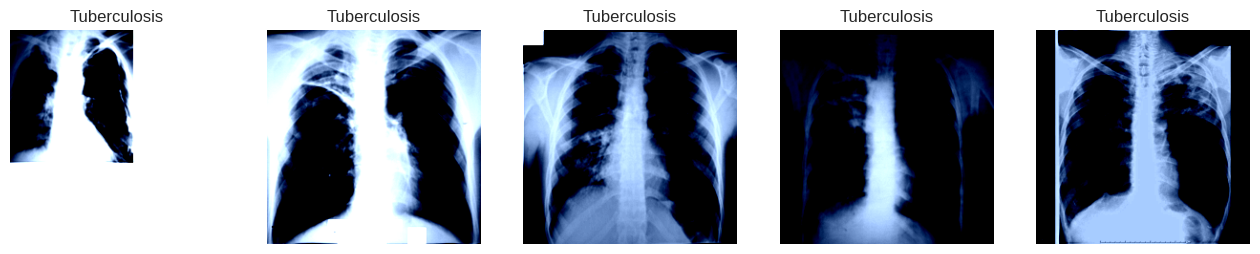

In [41]:
# fig = plt.figure(figsize=(16,16))
# for i in np.arange(10):
#     img = train_images[i]
#     # label = class_names[train_labels[i].item()]
#     label = train_labels[i].item()
#     ax = fig.add_subplot(1, 10, i+1)
#     ax.axis('off')
#     ax.imshow(img.permute(1, 2, 0))
#     ax.set_title(label)
    
images_per_class = 5
for i in range(len(class_names)):
    class_indices = [idx for idx, label in enumerate(train_set.targets) if label == i]
    print(f"Class '{class_names[i]}' has {len(class_indices)} samples.")
    selected_indices = np.random.choice(class_indices, images_per_class, replace=False)
    fig = plt.figure(figsize=(16, 16))
    for j, idx in enumerate(selected_indices):
        img = train_set[idx][0]
        label = class_names[train_set[idx][1]]
        ax = fig.add_subplot(1, images_per_class, j + 1)
        ax.axis('off')
        ax.imshow(img.permute(1, 2, 0))
        ax.set_title(label)

In [42]:
import os
import csv
import time
import torch


def train_model(model, train_loader, criterion, optimizer, num_epochs, save_path, val_loader=None, csv_path="training_stats.csv"):

    history = []
    total_start_time = time.time()

    for epoch in range(num_epochs):

        epoch_start_time = time.time()

        model.train()

        running_loss = 0.0
        correct = 0
        total = 0
        current = 0

        for images, labels in train_loader:

            current += images.size(0)

            print(f"Epoch {epoch+1}/{num_epochs} - Progress: {current}/{len(train_loader.dataset)}", end="\r")

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader.dataset)
        train_acc = correct / total

        val_loss = None
        val_acc = None

        if val_loader is not None:

            model.eval()

            val_running_loss = 0.0
            val_correct = 0
            val_total = 0

            with torch.no_grad():

                for images, labels in val_loader:

                    images = images.to(device)
                    labels = labels.to(device)

                    outputs = model(images)
                    loss = criterion(outputs, labels)

                    val_running_loss += loss.item() * images.size(0)

                    _, predicted = torch.max(outputs, 1)

                    val_total += labels.size(0)
                    val_correct += (predicted == labels).sum().item()

            val_loss = val_running_loss / len(val_loader.dataset)
            val_acc = val_correct / val_total

        epoch_time = time.time() - epoch_start_time

        history.append({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "train_accuracy": train_acc,
            "val_loss": val_loss,
            "val_accuracy": val_acc,
            "epoch_time_seconds": epoch_time
        })

        if val_loader is not None:
            print(f"Epoch [{epoch+1}/{num_epochs}] Train Loss: {train_loss:.4f} Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Val Acc: {val_acc:.4f} | Time: {epoch_time:.2f}s")
        else:
            print(f"Epoch [{epoch+1}/{num_epochs}] Train Loss: {train_loss:.4f} Train Acc: {train_acc:.4f} | Time: {epoch_time:.2f}s")

    total_time = time.time() - total_start_time

    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    os.makedirs("outputs", exist_ok=True)

    torch.save(model.state_dict(), save_path)

    with open(f"outputs/{csv_path}", "w", newline="") as f:

        writer = csv.DictWriter(f, fieldnames=["epoch", "train_loss", "train_accuracy", "val_loss", "val_accuracy", "epoch_time_seconds"])

        writer.writeheader()
        writer.writerows(history)

    print(f"Model saved to {save_path}")
    print(f"Training statistics saved to outputs/{csv_path}")
    print(f"Total training time: {total_time:.2f}s")

    return history

In [43]:
def evaluate_model(model, test_loader, test_set, model_name=None, plot_cm=True):
    test_outputs = utils.get_all_preds(model, test_loader)  # already eval

    probs = torch.softmax(test_outputs, dim=1)
    _, predicted = torch.max(probs, dim=1)

    y_true = torch.as_tensor(test_set.targets)
    y_pred = predicted.cpu()
    y_prob = probs[:, 1].cpu()  # class 1 = TB

    print(classification_report(
        y_true,
        y_pred,
        target_names=test_set.classes,
        digits=4,
        zero_division=0
    ))

    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "AUROC": roc_auc_score(y_true, y_prob)
    }

    if plot_cm:
        test_confmat = utils.get_confmat(test_set, test_outputs.cpu())

        if model_name is None:
            model_name = type(model).__name__.lower()

        plot_confmat(test_confmat, test_set.classes, model_name)

    fpr, tpr, thresholds = roc_curve(y_true, y_prob)

    return {
        "metrics": metrics,
        "y_true": y_true.numpy(),
        "y_pred": y_pred.numpy(),
        "y_prob": y_prob.numpy(),
        "fpr": fpr,
        "tpr": tpr,
        "thresholds": thresholds
    }

### ResNet18

In [44]:
# load resnet18 and train it
# load resetnet18

# resnet18 = torch.hub.load('pytorch/vision:v0.10.0', 'resnet18', pretrained=True)
resnet18 = torch.hub.load('pytorch/vision:v0.10.0', 'resnet18', pretrained=True)
resnet18.fc = torch.nn.Linear(resnet18.fc.in_features, len(class_names))

summary(resnet18)
# we can see how resnet18 has nearly 25M parameters

resnet18.to(device)

Using cache found in /home/jordicr2003/.cache/torch/hub/pytorch_vision_v0.10.0
/home/jordicr2003/MERIT/enviro/lib64/python3.14/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/jordicr2003/MERIT/enviro/lib64/python3.14/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [45]:
# criterion will be cross entropy loss since we have a classification problem
# optimizer will be Adam with a learning rate of 1e-4

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    resnet18.parameters(),
    lr=3e-5,
    weight_decay=1e-4
)

NUM_EPOCHS = 5

train_model(resnet18, train_loader, criterion, optimizer, NUM_EPOCHS, "models/resnet18.pth", val_loader=val_loader, csv_path=f"stats_resnet18_{NUM_EPOCHS}epochs.csv")

Epoch [1/5] Train Loss: 0.1276 Train Acc: 0.9629 | Val Loss: 0.0171 Val Acc: 0.9984 | Time: 285.30s
Epoch [2/5] Train Loss: 0.0262 Train Acc: 0.9946 | Val Loss: 0.0098 Val Acc: 0.9984 | Time: 280.29s
Epoch [3/5] Train Loss: 0.0162 Train Acc: 0.9966 | Val Loss: 0.0087 Val Acc: 0.9984 | Time: 320.76s
Epoch [4/5] Train Loss: 0.0069 Train Acc: 0.9990 | Val Loss: 0.0098 Val Acc: 0.9968 | Time: 291.01s
Epoch [5/5] Train Loss: 0.0039 Train Acc: 0.9997 | Val Loss: 0.0029 Val Acc: 0.9984 | Time: 282.84s
Model saved to models/resnet18.pth
Training statistics saved to outputs/stats_resnet18_5epochs.csv
Total training time: 1460.19s


[{'epoch': 1,
  'train_loss': 0.1276111909473209,
  'train_accuracy': 0.9629125552909152,
  'val_loss': 0.01712626103821787,
  'val_accuracy': 0.9984126984126984,
  'epoch_time_seconds': 285.29855704307556},
 {'epoch': 2,
  'train_loss': 0.02620056150233935,
  'train_accuracy': 0.99455597141885,
  'val_loss': 0.009800449214480256,
  'val_accuracy': 0.9984126984126984,
  'epoch_time_seconds': 280.28524470329285},
 {'epoch': 3,
  'train_loss': 0.016154996792897683,
  'train_accuracy': 0.9965974821367812,
  'val_loss': 0.008684238807773144,
  'val_accuracy': 0.9984126984126984,
  'epoch_time_seconds': 320.755987405777},
 {'epoch': 4,
  'train_loss': 0.006937325825929317,
  'train_accuracy': 0.9989792446410344,
  'val_loss': 0.009835037238857088,
  'val_accuracy': 0.9968253968253968,
  'epoch_time_seconds': 291.0087659358978},
 {'epoch': 5,
  'train_loss': 0.0038678125331094966,
  'train_accuracy': 0.9996597482136781,
  'val_loss': 0.0028636329268111795,
  'val_accuracy': 0.998412698412698

### EfficientNetB0

In [46]:
# load efficientnetb0 and train it
efficientnet = torch.hub.load('NVIDIA/DeepLearningExamples:torchhub', 'nvidia_efficientnet_b0', pretrained=True)

# per veure com és la part de classificiació i veure quants inputs ha de tenir l'última capa per adaptar-la
# print(efficientnet.classifier) # veiem que té una última linear de 1000 outputs i 1280 inputs
efficientnet.classifier[-1] = torch.nn.Linear(efficientnet.classifier[-1].in_features, len(class_names))

summary(efficientnet)
efficientnet.to(device)

Using cache found in /home/jordicr2003/.cache/torch/hub/NVIDIA_DeepLearningExamples_torchhub
/home/jordicr2003/.cache/torch/hub/NVIDIA_DeepLearningExamples_torchhub/PyTorch/Classification/ConvNets/image_classification/models/common.py:13: UserWarning: pytorch_quantization module not found, quantization will not be available
  warnings.warn(
/home/jordicr2003/.cache/torch/hub/NVIDIA_DeepLearningExamples_torchhub/PyTorch/Classification/ConvNets/image_classification/models/efficientnet.py:17: UserWarning: pytorch_quantization module not found, quantization will not be available
  warnings.warn(


EfficientNet(
  (stem): Sequential(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.010000000000000009, affine=True, bias=True, track_running_stats=True)
    (activation): SiLU(inplace=True)
  )
  (layers): Sequential(
    (0): Sequential(
      (block0): MBConvBlock(
        (depsep): Sequential(
          (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.010000000000000009, affine=True, bias=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (se): SequentialSqueezeAndExcitation(
          (squeeze): Linear(in_features=32, out_features=8, bias=True)
          (expand): Linear(in_features=8, out_features=32, bias=True)
          (activation): SiLU(inplace=True)
          (sigmoid): Sigmoid()
          (mul_a_quantizer): Identity()
          (mul_b_quantizer): Ident

In [ ]:
# criterion will be cross entropy loss since we have a classification problem
# optimizer will be Adam with a learning rate of 1e-4

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    efficientnet.parameters(),
    lr=3e-5,
    weight_decay=1e-4
)

train_model(efficientnet, train_loader, criterion, optimizer, NUM_EPOCHS, "models/efficientnet.pth", val_loader=val_loader, csv_path=f"stats_efficientnet_{NUM_EPOCHS}epochs.csv")

Epoch [1/5] Train Loss: 0.3394 Train Acc: 0.9337 | Val Loss: 0.2787 Val Acc: 0.9651 | Time: 384.34s
Epoch [2/5] Train Loss: 0.0714 Train Acc: 0.9905 | Val Loss: 0.0868 Val Acc: 0.9857 | Time: 353.59s
Epoch [3/5] Train Loss: 0.0272 Train Acc: 0.9949 | Val Loss: 0.0234 Val Acc: 0.9968 | Time: 401.39s
Epoch [4/5] Train Loss: 0.0143 Train Acc: 0.9983 | Val Loss: 0.0070 Val Acc: 0.9984 | Time: 406.63s
Epoch 5/5 - Progress: 560/2939

### Evaluation

In [ ]:
# load both models from /models and evaluate them

resnet18 = torch.hub.load('pytorch/vision:v0.10.0', 'resnet18', pretrained=False)
resnet18.fc = torch.nn.Linear(resnet18.fc.in_features, len(class_names))
resnet18.load_state_dict(torch.load("models/resnet18.pth"))
resnet18.to(device)

efficientnet = torch.hub.load('NVIDIA/DeepLearningExamples:torchhub', 'nvidia_efficientnet_b0', pretrained=False)
efficientnet.classifier[-1] = torch.nn.Linear(efficientnet.classifier[-1].in_features, len(class_names))
efficientnet.load_state_dict(torch.load("models/efficientnet.pth"))
efficientnet.to(device) 

In [ ]:
evaluate_model(resnet18, test_loader, test_set)

In [ ]:
evaluate_model(efficientnet, test_loader, test_set)

Surprisingly, both models perform extremely well, achieving performances of 99% after a few epochs. This could be for different reasons:
* Dataset being too easy or small, making the complex models learn patterns easily
* Data leaking, because of how the data is split. This was reviewed multiple times, and ruled out: splits are independent; no patient-level information is given to be able to split by patient, though. A full cleanup was performed
  * Leaking could also come from the dataset source: wrongly curated dataset could have similar images (or duplicates) in the training and validation/test sets 
* Models pretrained on similar datasets: this is ruled out, as the models were pretrained on ImageNet, which is a dataset of natural images, and not medical images. 
* External, non-medical features being learned. This includes things like text or other artifacts in the image that can be correlated with the class label, but are not actually medical features
  * Could happen if many TB images contain an annotation, for example.
  
The steps below aim to investigate the last point, by looking at the Grad-CAMs of the images, and seeing if the models are indeed using medical features (such as the lungs) to make their predictions, or if they are using external features (such as text or other artifacts in the image).


### Analysis via Grad-CAMs

In [ ]:
def plot_gradcam(image_tensor, cam, filename=None):
    # Check if inputs are tensors and convert appropriately
    if isinstance(image_tensor, torch.Tensor):
        # Remove batch dimension and move to CPU
        image_np = image_tensor.squeeze().cpu().numpy()
    else:
        # Already a numpy array
        image_np = image_tensor.squeeze()
    
    if isinstance(cam, torch.Tensor):
        cam_np = cam.squeeze().cpu().numpy()
    else:
        # Already a numpy array
        cam_np = cam.squeeze()
    # Rescale image for visualization
    image_np = (image_np - image_np.min()) / (image_np.max() - image_np.min())

    # Plot side-by-side
    plt.style.use('default')
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))

    # Image
    ax[0].imshow(np.transpose(image_np, (1, 2, 0)))
    ax[0].set_title("Original Image")
    ax[0].axis('off')
    # Grad-CAM heatmap
    ax[1].imshow(np.transpose(image_np, (1, 2, 0)))
    ax[1].imshow(cam_np, cmap='jet', alpha=0.5)
    ax[1].set_title("Grad-CAM Overlay")
    ax[1].axis('off')
    
    # Save and show
    if filename:
        plt.savefig(Path(filename), bbox_inches='tight')
    plt.show()
    

def gradcam_comparison(model, dataset, target_class, num_images=10, target_layer=None):
    model.eval()

    if target_layer is None:
        target_layer = model.layer4[-1].conv2

    selected_indices = []

    for idx in range(len(dataset)):
        _, label = dataset[idx]

        if torch.is_tensor(label):
            label = label.item()

        if label == target_class:
            selected_indices.append(idx)

        if len(selected_indices) >= num_images:
            break

    if len(selected_indices) == 0: raise ValueError(f"No images found for class {target_class}")

    cam_obj = GradCAM(model=model, target_layer=target_layer)

    fig, axes = plt.subplots(len(selected_indices), 2, figsize=(8, 4 * len(selected_indices)))

    if len(selected_indices) == 1:
        axes = [axes]

    for row, idx_image in enumerate(selected_indices):
        image, label = dataset[idx_image]

        if torch.is_tensor(label):
            label = label.item()

        input_image = image.unsqueeze(0).to(device)
        _, dense_cam = cam_obj(input_image, label)

        img = image.permute(1, 2, 0).cpu().numpy()
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)

        if img.shape[-1] == 1:
            img_display = img.squeeze(-1)
            cmap = "gray"
        else:
            img_display = img
            cmap = None

        axes[row][0].imshow(img_display, cmap=cmap)
        axes[row][0].set_title(f"Original | Idx: {idx_image} | Label: {label}")
        axes[row][0].axis("off")

        axes[row][1].imshow(img_display, cmap=cmap)
        axes[row][1].imshow(dense_cam, cmap="jet", alpha=0.4)
        axes[row][1].set_title("Grad-CAM")
        axes[row][1].axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
gradcam_comparison(resnet18, test_set, target_class=0, num_images=5)
gradcam_comparison(resnet18, test_set, target_class=1, num_images=5)

## Imbalance comparison

This step will compare the performance of the model with different imbalance techniques:
* No correction (dataset as it is)
* Oversampling
* Undersampling
* Class weights
* Data augmentation

This idea is to discover which technique works best for our dataset, and if it is worth applying any of them. As mentioned, the model we will be using for this comparison is the EfficientNetB0, as it was the best performing model in the previous step.

For consistency and comparability, the same number of epochs and the same learning rate will be used for all techniques. The only thing that will change is the way the data is fed to the model (either by using a different dataloader, or by applying class weights to the loss function).


### No correction

No data augmentation is applied. The results of this technique are the same as the ones obtained in the previous step, with a recall of 0.20.

### Oversampling

This method consists in oversampling the minority class by duplicating the images of that class. This can be done by using the `torch.utils.data.WeightedRandomSampler` class, which allows us to sample from the dataset with replacement, and to assign a weight to each sample. The weight is inversely proportional to the frequency of the class in the dataset, which means that the minority class will have a higher weight, and will be sampled more often.

It's important that oversampling is only applied to the training set, and not to the validation/test sets, as this would lead to data leakage.

In [ ]:
train_set = datasets.ImageFolder(root=utils.dirs['train'], transform=utils.transform['train'])
targets = np.array(train_set.targets)
class_counts = np.bincount(targets)

class_weights = 1.0 / class_counts
sample_weights = class_weights[targets]

sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(sample_weights),
    replacement=True
)

train_loader_oversample = DataLoader(train_set, batch_size=BATCH_SIZE, sampler=sampler, shuffle=False, num_workers=2)

sampled_indices = list(sampler)
sampled_targets = [train_set.targets[i] for i in sampled_indices]
print(f"Sampled targets [0 = Normal, 1 = TB]: {Counter(sampled_targets)}")

plt.figure(figsize=(6, 4))
sns.barplot(x=class_names, y=Counter(sampled_targets).values())
plt.title("Class distribution in the training set")
plt.ylabel("Number of samples")
plt.xlabel("Class")

In [ ]:
resnet18 = utils.get_resnet18(out_classes=len(class_names), pretrained=True)

criterion = torch.nn.CrossEntropyLoss()
optimizer = optim.AdamW(resnet18.parameters(), lr=3e-5, weight_decay=1e-4)

train_model(resnet18, train_loader_oversample, criterion, optimizer, NUM_EPOCHS, 
            "models/resnet18_oversampling.pth", val_loader=val_loader, csv_path=f"stats_resnet18_oversampling_{NUM_EPOCHS}epochs.csv"
)

### Undersampling

This method consists in undersampling the majority class by randomly selecting a subset of the images of that class. This can be done by using the `numpy.random.choice` function, which allows us to randomly select a subset of the indices of the majority class. The idea is to randomly select the same number of images in the minority class, thus undersampling the majority class.

In [ ]:
train_set = datasets.ImageFolder(root=utils.dirs['train'], transform=utils.transform['train'])

targets = np.array(train_set.targets)

# Count samples per class
class_counts = np.bincount(targets)
print(f"Original counts [0 = Normal, 1 = TB]: {class_counts}")

# Minority class size
min_count = np.min(class_counts)

# Collect indices for each class
indices_per_class = [np.where(targets == cls)[0] for cls in range(len(class_counts))]

# Random undersampling (sense replace)
undersampled_indices = np.hstack([np.random.choice(indices, min_count, replace=False) for indices in indices_per_class])

# Shuffle indices (canviem ordre per evitar que pugui aprendre un ordre)
np.random.shuffle(undersampled_indices)

# Create subset
undersampled_dataset = torch.utils.data.Subset(train_set, undersampled_indices) 

train_loader_undersample = DataLoader(undersampled_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

# Verify counts
undersampled_targets = [targets[i] for i in undersampled_indices]
print(f"Undersampled targets [0 = Normal, 1 = TB]: {Counter(undersampled_targets)}")

plt.figure(figsize=(6, 4))
sns.barplot(x=class_names, y=Counter(undersampled_targets).values())
plt.title("Class distribution in the training set")
plt.ylabel("Number of samples")
plt.xlabel("Class")

In [ ]:
resnet18 = utils.get_resnet18(out_classes=len(class_names), pretrained=True)

criterion = torch.nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    resnet18.parameters(),
    lr=3e-5,
    weight_decay=1e-4
)

train_model(resnet18, train_loader_undersample, criterion, optimizer, NUM_EPOCHS, "models/resnet18_undersampling.pth", 
            val_loader=val_loader, csv_path=f"stats_resnet18_undersampling_{NUM_EPOCHS}epochs.csv")

As expected, training time is much lower, as we are training on a much smaller dataset (around 1/3).

### Class weight correlation

In this section we compute the weight for each section and retrain the module using the parameter in weight from torch.nn.CrossEntropyLoss

In [ ]:
# Cmpute class weights for the training set
class_weights = imbalance_utils.get_class_weights(train_set)
print(f"Class weights: {class_weights}")

resnet18 = utils.get_resnet18(out_classes=len(class_names), pretrained=True)

criterion = torch.nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer = optim.AdamW(
    resnet18.parameters(),
    lr=3e-5,
    weight_decay=1e-4
)

train_model(resnet18, train_loader, criterion, optimizer, NUM_EPOCHS, "models/resnet18_class_weights.pth", val_loader=val_loader, csv_path=f"stats_resnet18_class_weights_{NUM_EPOCHS}epochs.csv")

### Augmentation

This step consists in applying data augmentation to the training set, to increase the dataset size. We'll be using the `torchvision.transforms` module to apply different data augmentation techniques, such as random rotations, and random crops. This step can also be used to remove potential features the model could be learning that are not medical features, which many times are in the borders.

In medical context we must be careful that such transformations do not remove or alter medical features, as this could lead to a decrease in performance. For example, random crops could remove parts of the lungs, which are the most important features for this task, or horizontal flips could change the position of the heart, which is another important feature for this task. 

In [ ]:
aug_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3), # to remove blueish color from TB class
    transforms.Resize((224, 224)),
    # transforms.RandomHorizontalFlip(p=0.5), # careful with this
    transforms.RandomRotation(degrees=10), # rotation
    transforms.RandomAffine( # random translation and scaling (rotation applied before)
        degrees=0,
        translate=(0.05, 0.05),
        scale=(0.95, 1.05)
    ),
    transforms.ColorJitter( # changes in brightness and contrast
        brightness=0.1,
        contrast=0.1
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_set_aug = datasets.ImageFolder(root=utils.dirs['train'], transform=aug_transform)
train_loader_aug = DataLoader(train_set_aug, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

In [ ]:
resnet18 = utils.get_resnet18(out_classes=len(class_names), pretrained=True)

criterion = torch.nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    resnet18.parameters(),
    lr=3e-5,
    weight_decay=1e-4
)

train_model( resnet18, train_loader_aug, criterion, optimizer, NUM_EPOCHS, "models/resnet18_augmentation.pth", 
            val_loader=val_loader, csv_path=f"stats_resnet18_augmentation_{NUM_EPOCHS}epochs.csv"
)

### Comparison

This section will evaluate the results of all the techniques, and compare them. The models will be loaded from the saved checkpoints, and evaluated on the same test set, to ensure comparability. The results will be compared in terms of recall, precision, F1-score, and AUC-ROC.

In [ ]:
models_to_evaluate = {
    "No correction": "models/resnet18.pth",
    "Oversampling": "models/resnet18_oversampling.pth",
    "Undersampling": "models/resnet18_undersampling.pth",
    "Class weights": "models/resnet18_class_weights.pth",
    "Augmentation": "models/resnet18_augmentation.pth"
}

results = {}
roc_data = {}

for name, path in models_to_evaluate.items():
    resnet18 = utils.get_resnet18(out_classes=len(class_names), pretrained=False)
    resnet18.load_state_dict(torch.load(path, map_location=device))
    resnet18.to(device)

    results[name] = evaluate_model(
        resnet18,
        test_loader,
        test_set,
        model_name=name
    )

In [ ]:
results_df = pd.DataFrame({
    name: result["metrics"]
    for name, result in results.items()
}).T

display(results_df)

plt.figure(figsize=(7, 6))

for name, result in results.items():
    plt.plot(
        result["fpr"],
        result["tpr"],
        label=f"{name} (AUC = {result['metrics']['AUROC']:.3f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

## Hyperparameter tuning

To find the best hyperparameters for our resnet18 model, we used Optuna, an automatic hyperparameter optimization framework. Basically, we created a function named 'objective' that evaluates the training process.

In [ ]:
def objective(trial):
    #Hyperparameters to test here we chose the parameters and the range
    lr = trial.suggest_float("lr", 1e-5, 1e-3, log=True) 
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [8, 16, 32])
    optimizer_name = trial.suggest_categorical("optimizer", ["AdamW", "SGD"])
    epoch = trial.suggest_categorical("batch_size", [2, 3, 6])

    #Load the model
    train_loader_t = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader_t   = DataLoader(val_set,   batch_size=batch_size, shuffle=False, num_workers=2)
    
    model = utils.get_resnet18(out_classes=len(class_names), pretrained=True).to(device)

    #Chose the optimizer
    criterion = nn.CrossEntropyLoss()
    if optimizer_name == "AdamW":
        optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        optimizer = optim.SGD(model.parameters(), lr=lr, weight_decay=weight_decay, momentum=0.9)
        
    history = train_model(
        model, train_loader_t, criterion, optimizer,
        num_epochs=epoch,
        save_path=f"models/trial_{trial.number}.pth",
        val_loader=val_loader_t,
        csv_path=f"trial_{trial.number}.csv"
    )

    #We return tha las value of the loss
    last=history[-1]
    
    return last['train_loss']

#We chose the combination with the lowest loss.
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=5)
print("Best Hyperparameters:", study.best_params)
    

## Evaluation

## Explainability